# Go/NoGo MRCP Classification — new sessions

Works with any recording from `gng_task.py`.
Only the **Config** cell needs editing between sessions.

In [32]:
import warnings
warnings.filterwarnings("ignore")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mne.filter import filter_data
from scipy.signal import welch
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

## Config

**Edit these three lines between sessions.**

In [33]:
PREFIX = "V"          # --prefix passed to gng_task.py
DATE   = "20260617"   # YYYYMMDD of the recording
ROOT   = "../data/subjectV"  # --out-dir passed to gng_task.py

# ── fixed params (don't change) ───────────────────────────────────────────────
FS            = 250.0
EPOCH_S       = 1.5
N_EPOCH       = int(EPOCH_S * FS)
LATE_MS       = 200;   N_LATE       = int(LATE_MS / 1000 * FS)
LATE_SLOPE_MS = 500;   N_LATE_SLOPE = int(LATE_SLOPE_MS / 1000 * FS)
N_SEGS        = 6

ALL_COLS      = [f"ch{i}" for i in range(16)]
CENTRAL_IDX   = [1, 3, 5, 9, 11, 13]       # F3 C3 P3 F4 C4 P4
CENTRAL_NAMES = ["F3", "C3", "P3", "F4", "C4", "P4"]
N_CH          = len(CENTRAL_IDX)
SEED          = 42

print(f"PREFIX={PREFIX}  DATE={DATE}  ROOT={ROOT}")

PREFIX=V  DATE=20260617  ROOT=../data/subjectV


## Load sessions

In [34]:
stamps = sorted(
    f.split("_")[-1][:-4]
    for f in os.listdir(ROOT)
    if f.startswith(f"{PREFIX}_eeg_{DATE}_") and f.endswith(".csv")
)
assert stamps, f"No files matching {PREFIX}_eeg_{DATE}_*.csv in {ROOT}"
print(f"Found {len(stamps)} session(s): {stamps}")

sessions = {}
for stamp in stamps:
    eeg_df = pd.read_csv(f"{ROOT}/{PREFIX}_eeg_{DATE}_{stamp}.csv")
    mrk_df = pd.read_csv(f"{ROOT}/{PREFIX}_markers_{DATE}_{stamp}.csv")

    raw_ts  = eeg_df["lsl_timestamp"].values
    raw_eeg = eeg_df[ALL_COLS].values.astype(np.float64)

    filt = filter_data(raw_eeg.T, FS, 0.5, 4.0, verbose=False).T
    filt -= filt.mean(axis=1, keepdims=True)              # CAR
    eeg_c = filt[:, CENTRAL_IDX].astype(np.float32)

    sessions[stamp] = (raw_ts, eeg_c, mrk_df)
    print(f"  {stamp}: {len(eeg_c):,} samples  {len(mrk_df)} markers")

Found 6 session(s): ['150226', '163354', '164144', '164714', '165256', '165815']
  150226: 87,304 samples  275 markers
  163354: 67,584 samples  251 markers
  164144: 64,981 samples  251 markers
  164714: 64,082 samples  253 markers
  165256: 65,556 samples  251 markers
  165815: 65,656 samples  252 markers


## Epoch extraction

In [35]:
def extract_epochs_session(stamp):
    ts, data, mrk = sessions[stamp]

    go_ts    = mrk.loc[mrk.marker_label == "go_onset",     "lsl_timestamp"].values
    hit_ts   = mrk.loc[mrk.marker_label == "hit",          "lsl_timestamp"].values
    press_ts = mrk.loc[mrk.marker_label == "button_press", "lsl_timestamp"].values
    nogo_ts  = mrk.loc[mrk.marker_label == "nogo_onset",   "lsl_timestamp"].values

    rts = [h - go_ts[go_ts < h][-1] for h in hit_ts if len(go_ts[go_ts < h])]
    median_rt = float(np.median(rts)) if rts else 0.8
    virtual_press_ts = nogo_ts + median_rt

    epochs, labels = [], []
    for ts_arr, label in [(press_ts, 1), (virtual_press_ts, 0)]:
        for ts0 in ts_arr:
            idx   = np.searchsorted(ts, ts0)
            start = idx - N_EPOCH
            if start >= 0 and idx <= len(data):
                epochs.append(data[start:idx])
                labels.append(label)

    return np.array(epochs, dtype=np.float32), np.array(labels, dtype=np.int8), median_rt


all_raw, all_y, all_sid = [], [], []
for sid, stamp in enumerate(stamps):
    raw, y, med_rt = extract_epochs_session(stamp)
    print(f"  Session {sid} ({stamp}): {(y==1).sum()} pos  {(y==0).sum()} neg  "
          f"median RT={med_rt*1000:.0f} ms")
    all_raw.append(raw)
    all_y.append(y)
    all_sid.append(np.full(len(y), sid, dtype=np.int32))

raw_all = np.concatenate(all_raw)
y_all   = np.concatenate(all_y)
s_all   = np.concatenate(all_sid)
print(f"\nTotal: {len(y_all)} epochs  {y_all.sum()} pos  shape {raw_all.shape}")

  Session 0 (150226): 73 pos  25 neg  median RT=499 ms
  Session 1 (163354): 49 pos  50 neg  median RT=592 ms
  Session 2 (164144): 50 pos  49 neg  median RT=605 ms
  Session 3 (164714): 52 pos  49 neg  median RT=474 ms
  Session 4 (165256): 49 pos  50 neg  median RT=359 ms
  Session 5 (165815): 51 pos  49 neg  median RT=340 ms

Total: 596 epochs  324 pos  shape (596, 375, 6)


## Grand-average MRCP

Check for a negative ramp at C3/C4 before t=0.

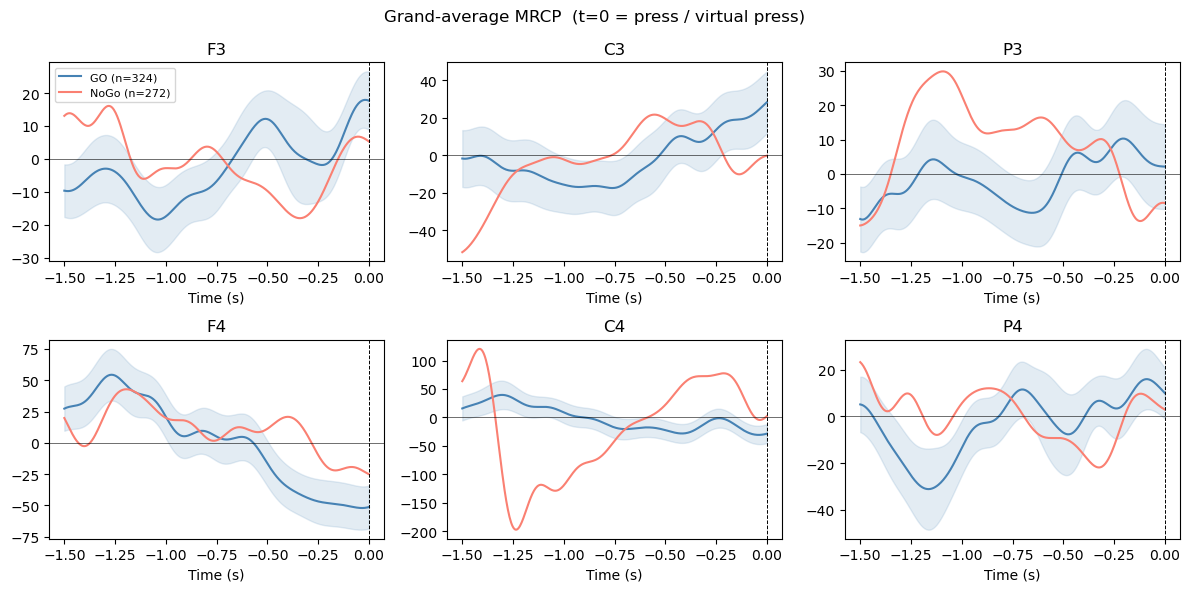

In [36]:
%matplotlib inline

t_ax = np.linspace(-EPOCH_S, 0, N_EPOCH)

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, (ch_i, ch_name) in zip(axes.flat, enumerate(CENTRAL_NAMES)):
    go_ep   = raw_all[y_all == 1][:, :, ch_i]
    nogo_ep = raw_all[y_all == 0][:, :, ch_i]
    ax.plot(t_ax, go_ep.mean(0),   color="steelblue", label=f"GO (n={len(go_ep)})")
    ax.plot(t_ax, nogo_ep.mean(0), color="salmon",    label=f"NoGo (n={len(nogo_ep)})")
    ax.fill_between(t_ax,
        go_ep.mean(0) - go_ep.std(0)/np.sqrt(len(go_ep)),
        go_ep.mean(0) + go_ep.std(0)/np.sqrt(len(go_ep)),
        alpha=0.15, color="steelblue")
    ax.axvline(0, color="k", linewidth=0.7, linestyle="--")
    ax.axhline(0, color="k", linewidth=0.4)
    ax.set_title(ch_name); ax.set_xlabel("Time (s)")
    if ch_i == 0: ax.legend(fontsize=8)

fig.suptitle("Grand-average MRCP  (t=0 = press / virtual press)")
plt.tight_layout(); plt.show()

## Feature extraction

In [37]:
def epoch_features(epoch):
    T = epoch.shape[0]
    baseline = epoch[:int(0.1 * FS)].mean(axis=0)
    ep = epoch - baseline
    t_c = np.arange(T, dtype=np.float64) - T / 2

    feat_mean  = ep.mean(axis=0)
    feat_slope = (ep * t_c[:, None]).sum(axis=0) / (t_c ** 2).sum()

    seg_size  = T // N_SEGS
    feat_segs = np.stack(
        [ep[i*seg_size:(i+1)*seg_size].mean(axis=0) for i in range(N_SEGS)]
    ).T.flatten()

    feat_late = ep[-N_LATE:].mean(axis=0)

    ep_ls = ep[-N_LATE_SLOPE:]
    t_ls  = np.arange(N_LATE_SLOPE, dtype=np.float64) - N_LATE_SLOPE / 2
    feat_late_slope = (ep_ls * t_ls[:, None]).sum(axis=0) / (t_ls ** 2).sum()

    _, psd  = welch(ep.T, fs=FS, nperseg=min(T, 128))
    freqs   = np.fft.rfftfreq(min(T, 128), 1.0 / FS)
    feat_delta = psd[:, (freqs >= 0.5) & (freqs <= 4.0)].mean(axis=1)

    return np.concatenate([
        feat_mean, feat_slope, feat_segs, feat_late, feat_late_slope, feat_delta
    ]).astype(np.float32)


X_all = np.array([epoch_features(e) for e in raw_all])
print(f"Feature matrix: {X_all.shape}")

Feature matrix: (596, 66)


## Leave-one-session-out CV

*(Skipped automatically if only 1 session — shows training metrics instead.)*

In [38]:
_rng = np.random.default_rng(SEED)

def balance(X, y, rng):
    idx0 = np.where(y == 0)[0]; idx1 = np.where(y == 1)[0]
    n    = min(len(idx0), len(idx1))
    idx  = np.concatenate([rng.choice(idx0, n, replace=False),
                           rng.choice(idx1, n, replace=False)])
    return X[np.sort(idx)], y[np.sort(idx)]

def make_clf():
    return make_pipeline(
        StandardScaler(),
        LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'),
    )

n_sessions   = len(stamps)
fold_results = []
all_probs    = []
all_true     = []

if n_sessions == 1:
    X_b, y_b = balance(X_all, y_all, _rng)
    clf = make_clf(); clf.fit(X_b, y_b)
    prob = clf.predict_proba(X_all)[:, 1]
    auc  = roc_auc_score(y_all, prob)
    ap   = average_precision_score(y_all, prob)
    fold_results.append(dict(session=0, stamp=stamps[0], auc=auc, ap=ap))
    all_probs.append(prob); all_true.append(y_all)
    print(f"  Single session (train=test):  AUC={auc:.4f}  AP={ap:.4f}  [not a generalisation estimate]")
else:
    for test_sid in range(n_sessions):
        tr = s_all != test_sid; te = s_all == test_sid
        X_tr_b, y_tr_b = balance(X_all[tr], y_all[tr], _rng)
        clf = make_clf(); clf.fit(X_tr_b, y_tr_b)
        prob = clf.predict_proba(X_all[te])[:, 1]
        auc  = roc_auc_score(y_all[te], prob)
        ap   = average_precision_score(y_all[te], prob)
        fold_results.append(dict(session=test_sid, stamp=stamps[test_sid], auc=auc, ap=ap))
        all_probs.append(prob); all_true.append(y_all[te])
        print(f"  Session {test_sid} ({stamps[test_sid]}):  AUC={auc:.4f}  AP={ap:.4f}  "
              f"(train {y_tr_b.sum()} pos + {(y_tr_b==0).sum()} neg)")

    mean_auc = np.mean([r['auc'] for r in fold_results])
    std_auc  = np.std( [r['auc'] for r in fold_results])
    mean_ap  = np.mean([r['ap']  for r in fold_results])
    print(f"\nLOSO  AUC = {mean_auc:.4f} ±{std_auc:.4f}   AP = {mean_ap:.4f}")

all_probs = np.concatenate(all_probs)
all_true  = np.concatenate(all_true)


  Session 0 (150226):  AUC=0.4860  AP=0.7668  (train 247 pos + 247 neg)
  Session 1 (163354):  AUC=0.6535  AP=0.6297  (train 222 pos + 222 neg)
  Session 2 (164144):  AUC=0.5502  AP=0.5346  (train 223 pos + 223 neg)
  Session 3 (164714):  AUC=0.5981  AP=0.6059  (train 223 pos + 223 neg)
  Session 4 (165256):  AUC=0.4506  AP=0.5240  (train 222 pos + 222 neg)
  Session 5 (165815):  AUC=0.5090  AP=0.5319  (train 223 pos + 223 neg)

LOSO  AUC = 0.5412 ±0.0686   AP = 0.5988


## Results

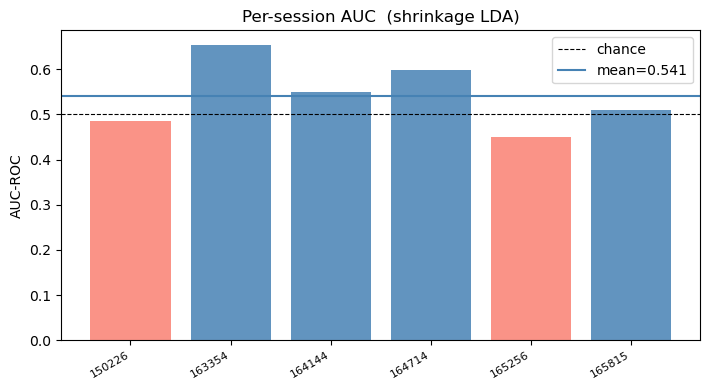

In [39]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(max(6, len(fold_results)*1.2), 4))
sids   = [r["session"] for r in fold_results]
aucs   = [r["auc"]     for r in fold_results]
colors = ["steelblue" if a >= 0.5 else "salmon" for a in aucs]
ax.bar(sids, aucs, color=colors, alpha=0.85)
ax.axhline(0.5, color="k", linestyle="--", linewidth=0.8, label="chance")
if len(fold_results) > 1:
    ax.axhline(mean_auc, color="steelblue", linestyle="-", linewidth=1.5,
               label=f"mean={mean_auc:.3f}")
ax.set_xticks(sids)
ax.set_xticklabels([r["stamp"] for r in fold_results], rotation=30, ha="right", fontsize=8)
ax.set_ylabel("AUC-ROC"); ax.set_title("Per-session AUC  (shrinkage LDA)")
ax.legend(); plt.tight_layout(); plt.show()

## Threshold Calibration

Aggregate ROC from all LOTO/LOSO folds — each epoch scored by the model
that never saw it during training.

Candidate thresholds:
- **Youden's J** — maximises sensitivity + specificity
- **Sens ≥ 0.80 / 0.90** — catch most presses
- **Spec ≥ 0.90 / 0.95** — low false-alarm rate (military priority)


In [ ]:
%matplotlib inline
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(all_true, all_probs)
spec = 1 - fpr

# candidate thresholds
j_idx      = np.argmax(tpr + spec - 1)                        # Youden's J
s80_idx    = np.argmax(tpr >= 0.80)                           # sens >= 0.80
s90_idx    = np.argmax(tpr >= 0.90)                           # sens >= 0.90
sp90_idx   = np.where(spec >= 0.90)[0][-1] if (spec >= 0.90).any() else 0
sp95_idx   = np.where(spec >= 0.95)[0][-1] if (spec >= 0.95).any() else 0

candidates = [
    ("Youden's J",   j_idx,    "steelblue"),
    ("Sens ≥ 0.80",  s80_idx,  "seagreen"),
    ("Sens ≥ 0.90",  s90_idx,  "limegreen"),
    ("Spec ≥ 0.90",  sp90_idx, "darkorange"),
    ("Spec ≥ 0.95",  sp95_idx, "tomato"),
]

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", linewidth=1.5,
        label=f"ROC  (AUC={mean_auc:.3f})")
ax.plot([0, 1], [0, 1], color="k", linewidth=0.6, linestyle="--")

for name, idx, color in candidates:
    ax.scatter(fpr[idx], tpr[idx], s=60, color=color, zorder=5,
               label=f"{name}  thr={thresholds[idx]:.3f}  "
                     f"sens={tpr[idx]:.2f}  spec={spec[idx]:.2f}")

ax.set_xlabel("False positive rate  (1 − specificity)")
ax.set_ylabel("True positive rate  (sensitivity)")
ax.set_title("Aggregate LOTO ROC — threshold calibration")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

# summary table
print(f"{'Name':<14} {'Threshold':>10} {'Sensitivity':>12} {'Specificity':>12}")
print("-" * 52)
for name, idx, _ in candidates:
    print(f"{name:<14} {thresholds[idx]:>10.3f} "
          f"{tpr[idx]:>12.3f} {spec[idx]:>12.3f}")
